In [15]:

#Imports
from thermopy.eos import PengRobinson, VanDerWaals
from thermopy.properties import fugacity
from scipy.optimize import brentq
import matplotlib.pyplot as plt
import numpy as np


## Generating vapour pressure curves using EoS and fugacity coefficients

190.0


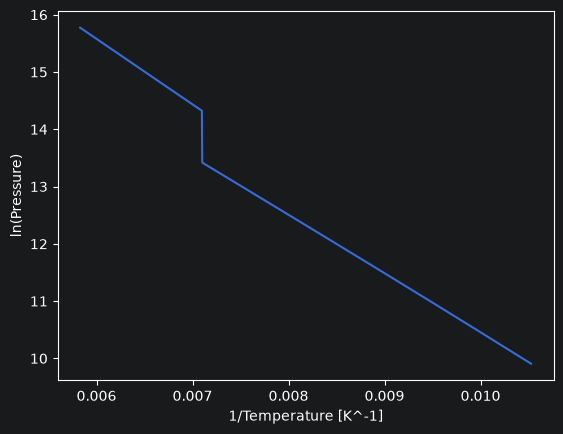

In [28]:
methane = PengRobinson("methane")

Tc = methane.Tc
print(np.floor(Tc))
Temperature_range = np.linspace(95, 0.9*Tc, 1000)
P_sats = []
C =6

for T in Temperature_range:
    tr = T/Tc
    p_rest = C*(1-1/tr)

    p_est = np.exp(p_rest) * methane.Pc

    #Define objective function
    def objectivef(p):
        state = methane.solve(T=T, P=p)

        #Assign each phase to its results
        liquid = state[0]
        vapour = state[-1]

        liq_phi = fugacity.coefficient(liquid, methane)
        vap_phi = fugacity.coefficient(vapour, methane)
        #function to find root of
        return liq_phi-vap_phi


    P_sats.append(brentq(objectivef, 0.5*p_est, 3*p_est))
T_inv = [1/t for t in Temperature_range]
logP_sats = [np.log(p) for p in P_sats]

plt.plot(T_inv, logP_sats)
plt.xlabel("1/Temperature [K^-1]")
plt.ylabel("ln(Pressure)")
plt.show()
